# Model Evaluation: Employment Forecaster

Evaluates the LightGBM employment forecaster trained by `src/train_model.py`. Includes a worked case study of a real bug found during development: an earlier version of this model, predicting absolute employment level, mispredicted the largest US occupation (Retail Salespersons) by ~60% -- see `docs/METHODOLOGY.md` for the full writeup. This notebook uses the fixed version (predicts log growth ratio instead).


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

from train_model import build_supervised, split, evaluate, FEATURE_COLS, TARGET_COL

features = pd.read_csv("../data/processed/oews_occupation_features.csv")
supervised = build_supervised(features)
train, val, test = split(supervised)
print(f"train={len(train)}  val={len(val)}  test={len(test)}")

model = lgb.Booster(model_file="../data/processed/employment_forecast_model.txt")


train=1276  val=1278  test=2647


## Metrics by split

In [2]:
for name, dset in [("train", train), ("val", val), ("test", test)]:
    evaluate(model, dset, name)


train        n= 1276  RMSE=      26,650  MAPE=  18.3%  median APE=  9.6%  RMSE(1M+ occ, n=20)=     180,266
val          n= 1278  RMSE=      26,420  MAPE=  15.1%  median APE=  9.6%  RMSE(1M+ occ, n=23)=     166,374
test         n= 2647  RMSE=      16,521  MAPE=  12.1%  median APE=  7.4%  RMSE(1M+ occ, n=52)=      91,548


## Feature importance

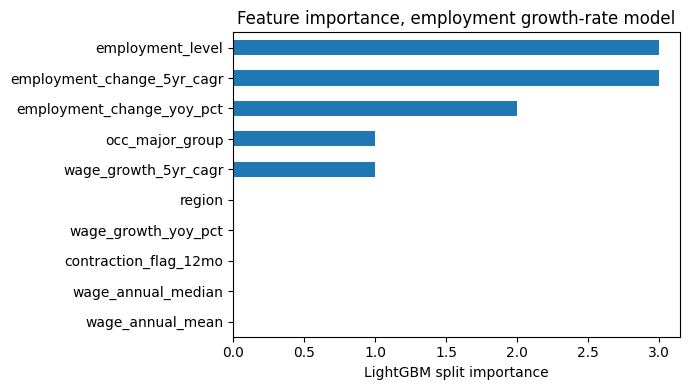

In [3]:
importance = pd.Series(model.feature_importance(), index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
importance.plot(kind="barh", ax=ax)
ax.set_xlabel("LightGBM split importance")
ax.set_title("Feature importance, employment growth-rate model")
plt.tight_layout()
plt.show()


## Case study: Retail Salespersons (the bug that motivated the growth-rate target)

The single largest US occupation (~3.6-3.8M employees). An earlier version of this model, trained on `log1p(employment_level)` directly, predicted ~1.4-2.1M here -- a 40-60% miss, including on rows it was trained on. Only 7 of 1,276 training rows exceed 2M employees, so the model had almost no signal at that scale. Switching the target to `log(employment_next / employment_now)` fixes it, shown below.

In [4]:
rows = supervised[(supervised["occ_code"] == "41-2031") & (supervised["region"] == "US")].sort_values("year")
preds = rows["employment_level"].values * np.exp(model.predict(rows[FEATURE_COLS]))
comparison = rows[["year", "employment_level", TARGET_COL]].copy()
comparison["predicted_next"] = preds
comparison["error_pct"] = (comparison["predicted_next"] - comparison[TARGET_COL]) / comparison[TARGET_COL] * 100
comparison


,year,employment_level,employment_level_next,predicted_next,error_pct
12465,2020,3659670.0,3693490.0,3.555133e+06,-3.745956
12466,2021,3693490.0,3640040.0,3.587987e+06,-1.429999
12467,2022,3640040.0,3684740.0,3.536064e+06,-4.034906
12468,2023,3684740.0,3800250.0,3.579487e+06,-5.809160


## Actual vs. predicted, full test set (log-log)

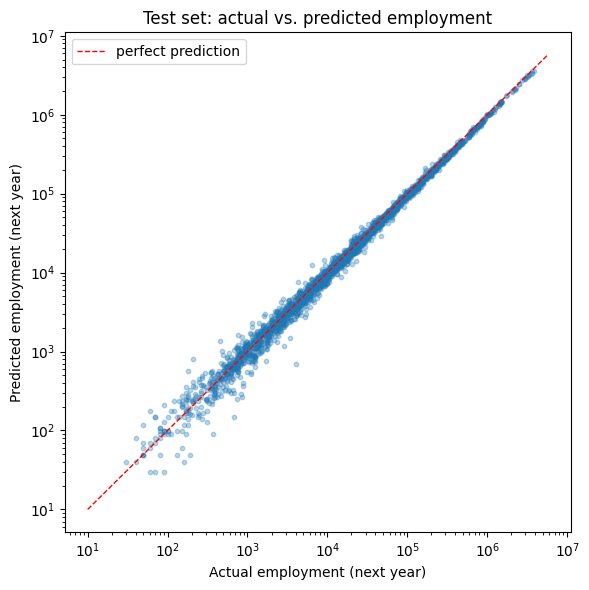

In [5]:
test_preds = test["employment_level"].values * np.exp(model.predict(test[FEATURE_COLS]))
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(test[TARGET_COL], test_preds, alpha=0.3, s=10)
lims = [10, test[TARGET_COL].max() * 1.5]
ax.plot(lims, lims, "r--", linewidth=1, label="perfect prediction")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Actual employment (next year)")
ax.set_ylabel("Predicted employment (next year)")
ax.set_title("Test set: actual vs. predicted employment")
ax.legend()
plt.tight_layout()
plt.show()
